# 🛡️ Aadhaar Card — YOLOv8 Field Detection Training

This notebook trains a **YOLOv8** model to detect key fields on an Aadhaar card:
- **Class 0** — Name region
- **Class 1** — Date of Birth region
- **Class 2** — Gender region
- **Class 3** — Address region
- **Class 4** — Aadhaar Number region

### 📋 Steps in this notebook:
1. Check GPU availability
2. Install dependencies
3. Upload & extract your dataset
4. Configure `data.yaml`
5. Train YOLOv8
6. Evaluate & visualize results
7. Download trained model (`best.pt`)

---
> ⚡ **Make sure Runtime → Change runtime type → GPU (T4) is selected before running!**

## ✅ Step 1 — Check GPU

In [1]:
import torch

print('='*50)
print('🖥️  GPU CHECK')
print('='*50)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f'✅ GPU Found: {gpu_name}')
    print(f'   Memory   : {gpu_mem:.1f} GB')
else:
    print('❌ No GPU detected!')
    print('   → Go to Runtime → Change runtime type → GPU')

print(f'   PyTorch  : {torch.__version__}')

🖥️  GPU CHECK
✅ GPU Found: Tesla T4
   Memory   : 14.6 GB
   PyTorch  : 2.11.0+cu128


## 📦 Step 2 — Install Dependencies

In [2]:
# Install Ultralytics (YOLOv8) — this takes ~1 minute
!pip install ultralytics --quiet

# Verify install
import ultralytics
ultralytics.checks()
print('✅ Ultralytics installed successfully!')

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)
✅ Ultralytics installed successfully!


## 📁 Step 3 — Upload Your Dataset

You have **two options** to get your dataset into Colab. Choose **ONE**:

### Option A — Upload a ZIP file directly (recommended for first time)
### Option B — Mount Google Drive (recommended if you re-run often)

Run whichever cell you prefer, then skip the other.

### 📤 Option A — Upload ZIP (Direct Upload)

**Before running this cell:**
1. Zip your `dataset` folder on your PC:
   - Right-click the `dataset` folder → Send to → Compressed (zipped) folder
   - Name it `dataset.zip`
2. Run the cell below and click **Choose Files** to upload it

In [3]:
# ─── OPTION A: Upload dataset ZIP ─────────────────────────────────────────────
import os
from google.colab import files

print('📤 Click the button below to upload your dataset.zip file...')
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f'\n✅ Uploaded: {zip_filename}')
print(f'   Size: {len(uploaded[zip_filename]) / (1024*1024):.1f} MB')

# Extract the zip
import zipfile
print('\n📂 Extracting dataset...')
with zipfile.ZipFile(zip_filename, 'r') as zf:
    zf.extractall('/content/dataset_raw')

# List extracted content
print('\n📋 Extracted files:')
for root, dirs, files_list in os.walk('/content/dataset_raw'):
    level = root.replace('/content/dataset_raw', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    if level < 2:
        subindent = '  ' * (level + 1)
        for f in files_list[:3]:
            print(f'{subindent}📄 {f}')
        if len(files_list) > 3:
            print(f'{subindent}... and {len(files_list)-3} more files')

print('\n✅ Dataset extracted successfully!')

📤 Click the button below to upload your dataset.zip file...


Saving dataset.zip to dataset.zip

✅ Uploaded: dataset.zip
   Size: 102.7 MB

📂 Extracting dataset...

📋 Extracted files:
📁 dataset_raw/
  📁 dataset/
    📄 README.roboflow.txt
    📄 README.dataset.txt
    📄 data.yaml
    📁 valid/
      📁 images/
      📁 labels/
    📁 train/
      📁 images/
      📁 labels/
    📁 test/
      📁 images/
      📁 labels/

✅ Dataset extracted successfully!


In [ ]:
# ─── OPTION B: Mount Google Drive ─────────────────────────────────────────────
# Use this if you already uploaded dataset.zip to your Google Drive

from google.colab import drive
drive.mount('/content/drive')

# CHANGE THIS PATH to wherever your dataset.zip is in your Drive
DRIVE_ZIP_PATH = '/content/drive/MyDrive/dataset.zip'  # ← Update this!

import zipfile, os
print(f'📂 Extracting from: {DRIVE_ZIP_PATH}')
with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
    zf.extractall('/content/dataset_raw')

print('✅ Dataset extracted from Google Drive!')

## 🗂️ Step 4 — Organize Dataset & Fix data.yaml

This step automatically detects your folder structure and fixes the `data.yaml` paths for Colab.

In [6]:
import os
import shutil
import yaml

RAW_ROOT = '/content/dataset_raw'
DATASET_DIR = '/content/dataset'

# ── Auto-detect dataset root (handles zip with/without subfolder) ─────────────
def find_dataset_root(base_path):
    """Find the folder that contains train/, valid/, test/ subfolders."""
    for root, dirs, files in os.walk(base_path):
        if any(d in dirs for d in ['train', 'valid', 'test']):
            return root
    return base_path

detected_root = find_dataset_root(RAW_ROOT)
print(f'📌 Detected dataset root: {detected_root}')

# ── Copy to clean path ────────────────────────────────────────────────────────
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
shutil.copytree(detected_root, DATASET_DIR)
print(f'✅ Dataset copied to: {DATASET_DIR}')

# ── Verify structure ──────────────────────────────────────────────────────────
print('\n📊 Dataset Structure:')
for split in ['train', 'valid', 'test']:
    img_path = os.path.join(DATASET_DIR, split, 'images')
    lbl_path = os.path.join(DATASET_DIR, split, 'labels')
    n_imgs = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    n_lbls = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0
    status = '✅' if n_imgs > 0 else '❌'
    print(f'  {status} {split:6s} → {n_imgs:4d} images  |  {n_lbls:4d} labels')

# ── Write corrected data.yaml ─────────────────────────────────────────────────
DATA_YAML_PATH = os.path.join(DATASET_DIR, 'data.yaml')

# Class names from original dataset (update these if you know the real names)
CLASS_NAMES = ['aadhaar_number', 'dob', 'gender', 'name', 'address']

data_yaml = {
    'path': DATASET_DIR,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    len(CLASS_NAMES),
    'names': CLASS_NAMES
}

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f'\n✅ data.yaml written to: {DATA_YAML_PATH}')
print('\n📄 data.yaml contents:')
with open(DATA_YAML_PATH) as f:
    print(f.read())

📌 Detected dataset root: /content/dataset_raw/dataset
✅ Dataset copied to: /content/dataset

📊 Dataset Structure:
  ✅ train  → 1852 images  |  1852 labels
  ✅ valid  →  529 images  |   529 labels
  ✅ test   →  265 images  |   265 labels

✅ data.yaml written to: /content/dataset/data.yaml

📄 data.yaml contents:
path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 5
names:
- aadhaar_number
- dob
- gender
- name
- address



## 🖼️ Step 5 — Preview Sample Images

Sanity check — let's visualize a few training images with their annotations.

/tmp/ipykernel_1446/139719004.py:88: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1446/139719004.py:89: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_annotations.png', dpi=120, bbox_inches='tight')


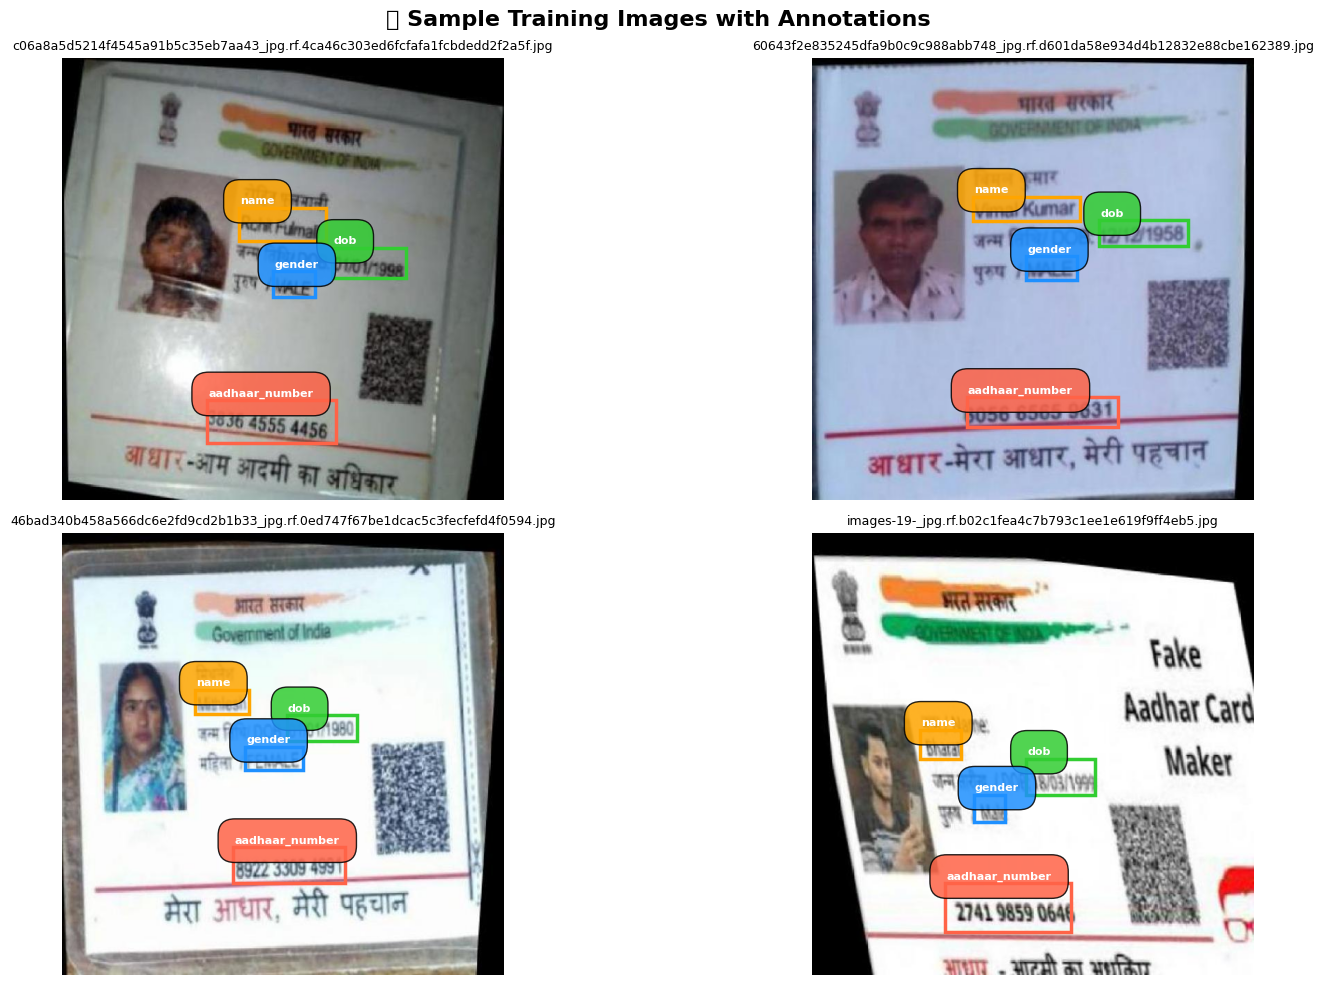

✅ Sample preview saved to /content/sample_annotations.png


In [7]:
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

COLORS = [
    (255,  99,  71),   # tomato   — name
    ( 50, 205,  50),   # lime     — dob
    ( 30, 144, 255),   # dodger   — gender
    (255, 165,   0),   # orange   — address
    (148,   0, 211),   # violet   — aadhaar number
]
CLASS_NAMES = ['aadhaar_number', 'dob', 'gender', 'name', 'address']

def draw_yolo_boxes(image_path, label_path, class_names, colors):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(image_path), fontsize=10)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                box_w = bw * w
                box_h = bh * h
                color = tuple(c/255 for c in colors[cls % len(colors)])
                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                label = class_names[cls] if cls < len(class_names) else str(cls)
                ax.text(x1, y1-4, label, color=color, fontsize=9,
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))
    return fig

# Pick 4 random training images
img_dir = '/content/dataset/train/images'
lbl_dir = '/content/dataset/train/labels'
img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]

sample = random.sample(img_files, min(4, len(img_files)))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('📸 Sample Training Images with Annotations', fontsize=16, fontweight='bold')

for idx, fname in enumerate(sample):
    img_path = os.path.join(img_dir, fname)
    lbl_path = os.path.join(lbl_dir, os.path.splitext(fname)[0] + '.txt')
    ax = axes[idx // 2][idx % 2]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fname, fontsize=9)

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                color = tuple(c/255 for c in COLORS[cls % len(COLORS)])
                rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                         linewidth=2.5, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                lname = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
                ax.text(x1+2, y1-5, lname, color='white', fontsize=8, fontweight='bold',
                        bbox=dict(facecolor=color, alpha=0.85, pad=1.5, boxstyle='round'))

plt.tight_layout()
plt.savefig('/content/sample_annotations.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample preview saved to /content/sample_annotations.png')

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🚀 Step 6 — Train YOLOv8

### ⚙️ Training Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| Model | `yolov8n.pt` | Nano — fast, good for text region detection |
| Epochs | 100 | Adjust if needed |
| Image size | 640 | Matches Roboflow preprocessing |
| Batch | 16 | Optimal for T4 GPU |
| Patience | 20 | Early stopping if no improvement |

> 🕐 **Estimated training time: 25–45 minutes on T4 GPU** for 2646 images × 100 epochs

In [9]:
from ultralytics import YOLO
import torch

# ── Training Configuration ────────────────────────────────────────────────────
MODEL_BASE   = 'yolov8n.pt'   # Base pretrained weights (auto-downloaded)
DATA_YAML    = '/content/dataset/data.yaml'
EPOCHS       = 100
IMAGE_SIZE   = 640
BATCH_SIZE   = 16             # Reduce to 8 if you get CUDA out-of-memory
PROJECT_NAME = 'Aadhaar_Detection'
RUN_NAME     = 'run1'
PATIENCE     = 20             # Early stopping
WORKERS      = 2

print('='*60)
print('🚀 STARTING YOLOV8 TRAINING')
print('='*60)
print(f'   Model      : {MODEL_BASE}')
print(f'   Data       : {DATA_YAML}')
print(f'   Epochs     : {EPOCHS}')
print(f'   Image size : {IMAGE_SIZE}px')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Device     : {"cuda" if torch.cuda.is_available() else "cpu"}')
print('='*60)

model = YOLO(MODEL_BASE)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    project=PROJECT_NAME,
    name=RUN_NAME,
    patience=PATIENCE,
    workers=WORKERS,
    device=0 if torch.cuda.is_available() else 'cpu',


    # ── Augmentation disabled ────────────────────────────────────────────────
    augment=False,
    mosaic=0.0,
    fliplr=0.0,


    # ── Optimizer ────────────────────────────────────────────────────────────
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,

    # ── Logging ──────────────────────────────────────────────────────────────
    verbose=True,
    save=True,
    save_period=10,   # save checkpoint every 10 epochs
    plots=True,
)

print('\n' + '='*60)
print('✅ TRAINING COMPLETE!')
print('='*60)

# Print key metrics
best_model_path = f'/content/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt'
last_model_path = f'/content/{PROJECT_NAME}/{RUN_NAME}/weights/last.pt'
print(f'📦 Best model : {best_model_path}')
print(f'📦 Last model : {last_model_path}')

🚀 STARTING YOLOV8 TRAINING
   Model      : yolov8n.pt
   Data       : /content/dataset/data.yaml
   Epochs     : 100
   Image size : 640px
   Batch size : 16
   Device     : cuda
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, ma

## 📊 Step 7 — Evaluate & Plot Results

📁 Results directory: /content/runs/detect/Aadhaar_Detection/run1

📋 Available result files:
   → BoxP_curve.png
   → labels.jpg
   → args.yaml
   → train_batch0.jpg
   → val_batch0_labels.jpg
   → val_batch1_labels.jpg
   → confusion_matrix.png
   → weights
   → train_batch10440.jpg
   → BoxR_curve.png
   → BoxPR_curve.png
   → train_batch2.jpg
   → val_batch2_labels.jpg
   → val_batch0_pred.jpg
   → results.csv
   → results.png
   → confusion_matrix_normalized.png
   → BoxF1_curve.png
   → val_batch1_pred.jpg
   → train_batch10441.jpg
   → val_batch2_pred.jpg
   → train_batch10442.jpg
   → train_batch1.jpg


/tmp/ipykernel_1446/1226979708.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


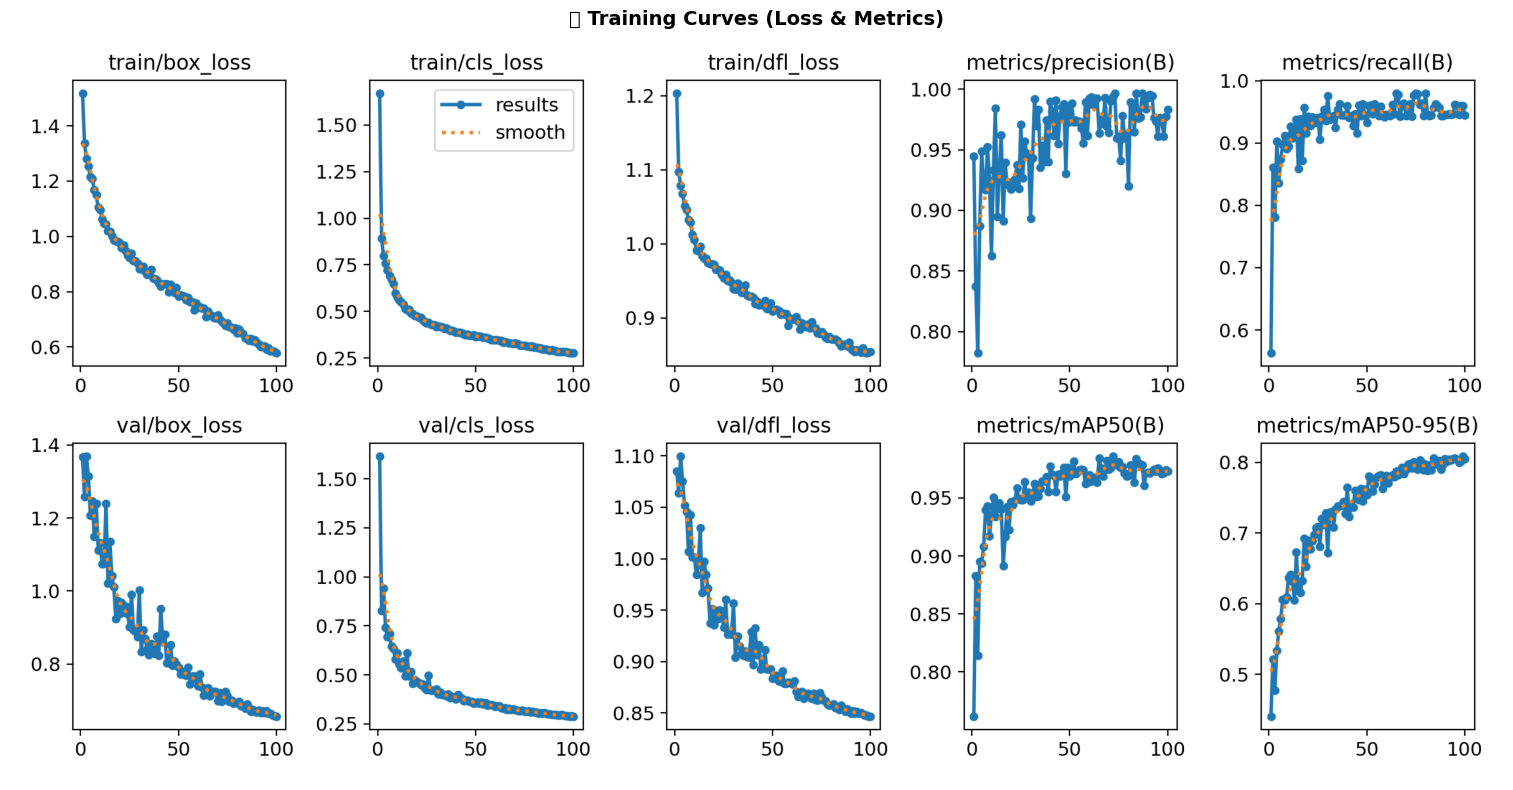

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


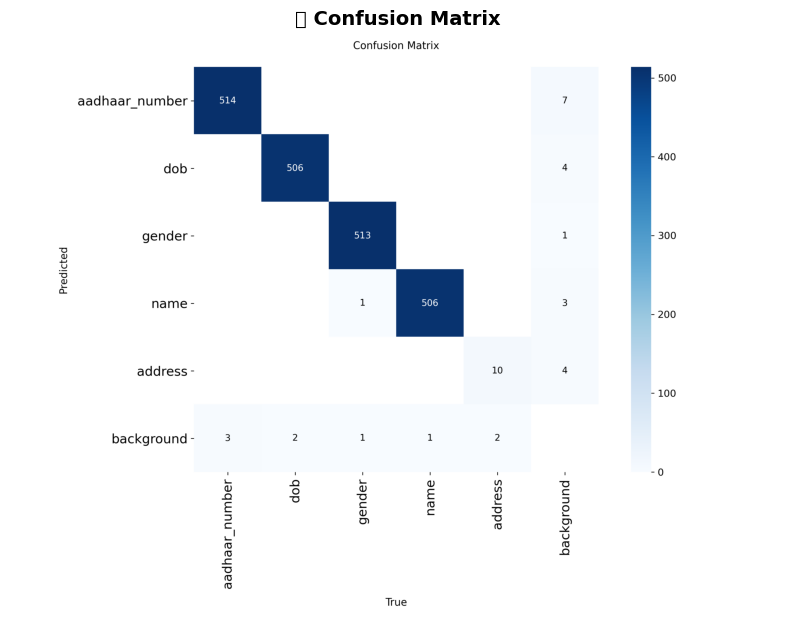

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

PROJECT_NAME = 'Aadhaar_Detection'
RUN_NAME     = 'run1'
RESULTS_DIR = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}'

print(f'📁 Results directory: {RESULTS_DIR}')
print('\n📋 Available result files:')
for f in os.listdir(RESULTS_DIR):
    print(f'   → {f}')

# ── Plot training curves ───────────────────────────────────────────────────────
curves_path = os.path.join(RESULTS_DIR, 'results.png')
if os.path.exists(curves_path):
    fig, ax = plt.subplots(figsize=(18, 8))
    img = mpimg.imread(curves_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('📈 Training Curves (Loss & Metrics)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ results.png not found yet — training may still be running')

# ── Plot confusion matrix ──────────────────────────────────────────────────────
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
if os.path.exists(cm_path):
    fig, ax = plt.subplots(figsize=(10, 8))
    img = mpimg.imread(cm_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('🔢 Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

# ── Plot PR curve ──────────────────────────────────────────────────────────────
pr_path = os.path.join(RESULTS_DIR, 'PR_curve.png')
if os.path.exists(pr_path):
    fig, ax = plt.subplots(figsize=(10, 7))
    img = mpimg.imread(pr_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('📐 Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.show()

## 🔬 Step 8 — Run Validation on Test Set

In [12]:
from ultralytics import YOLO

PROJECT_NAME    = 'Aadhaar_Detection'
RUN_NAME        = 'run1'
best_model_path = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt'
DATA_YAML       = '/content/dataset/data.yaml'

print('🔬 Running validation on TEST set...')
best_model = YOLO(best_model_path)

val_results = best_model.val(
    data=DATA_YAML,
    split='test',
    imgsz=640,
    conf=0.25,
    iou=0.5,
    verbose=True
)

print('\n' + '='*50)
print('📊 VALIDATION RESULTS (Test Set)')
print('='*50)

try:
    box = val_results.box
    print(f'  mAP@50      : {box.map50:.4f}  ({box.map50*100:.1f}%)')
    print(f'  mAP@50-95   : {box.map:.4f}  ({box.map*100:.1f}%)')
    print(f'  Precision   : {box.mp:.4f}')
    print(f'  Recall      : {box.mr:.4f}')

    CLASS_NAMES = ['name', 'dob', 'gender', 'address', 'aadhaar_number']
    print('\n  Per-class mAP@50:')
    for i, (ap, name) in enumerate(zip(box.ap50, CLASS_NAMES)):
        bar = '█' * int(ap * 20)
        print(f'    {name:20s}: {ap:.4f}  |{bar:<20}|')
except Exception as e:
    print(f'   (Could not parse detailed metrics: {e})')

print('='*50)

🔬 Running validation on TEST set...
Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 967.6±325.7 MB/s, size: 37.6 KB)
val: Scanning /content/dataset/test/labels... 265 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 265/265 1.8Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1038. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 2.7it/s 6.2s
                   all        265       1038      0.971      0.954      0.942      0.776
        aadhaar_number        257        263    

## 🖼️ Step 9 — Run Inference on Sample Test Images

/tmp/ipykernel_1446/272586874.py:56: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1446/272586874.py:57: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/inference_results.png', dpi=120, bbox_inches='tight')


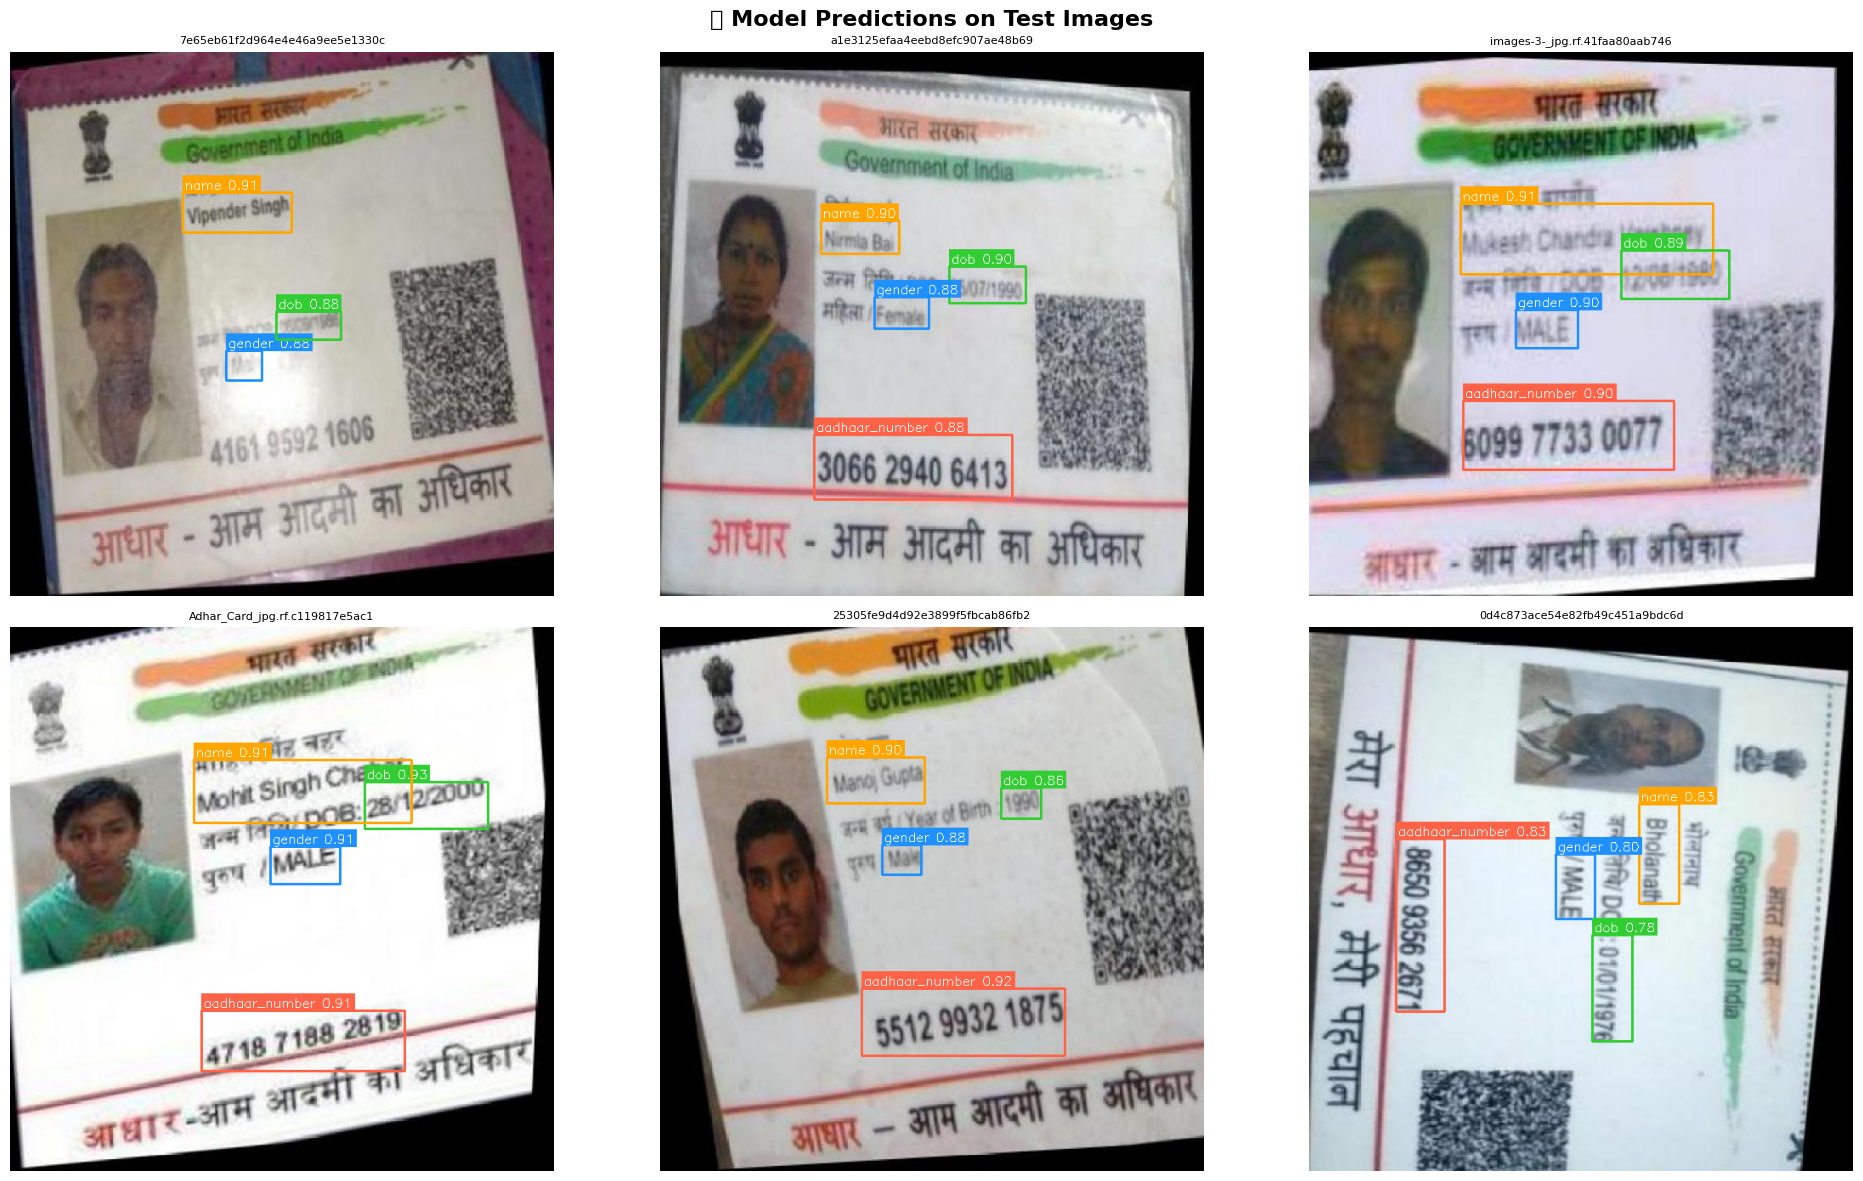

✅ Inference preview saved to /content/inference_results.png


In [14]:
import cv2
import matplotlib.pyplot as plt
import random
import os
import numpy as np
from ultralytics import YOLO

PROJECT_NAME    = 'Aadhaar_Detection'
RUN_NAME        = 'run1'
best_model_path = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}/weights/best.pt'

CLASS_NAMES = ['aadhaar_number', 'dob', 'gender', 'name', 'address']
COLORS = [
    (255, 99,  71),
    (50,  205, 50),
    (30,  144, 255),
    (255, 165, 0),
    (148, 0,   211),
]

model = YOLO(best_model_path)

test_img_dir = '/content/dataset/test/images'
test_files   = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
sample_files = random.sample(test_files, min(6, len(test_files)))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('🎯 Model Predictions on Test Images', fontsize=16, fontweight='bold')

for idx, fname in enumerate(sample_files):
    img_path = os.path.join(test_img_dir, fname)
    ax = axes[idx // 3][idx % 3]

    preds = model.predict(img_path, conf=0.25, verbose=False)[0]
    img   = cv2.imread(img_path)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        color = COLORS[cls % len(COLORS)]
        name  = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f'{name} {conf:.2f}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
        cv2.putText(img, label, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fname[:30], fontsize=8)

plt.tight_layout()
plt.savefig('/content/inference_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Inference preview saved to /content/inference_results.png')

## 💾 Step 10 — Save & Download the Trained Model

This downloads:
- `best.pt` — **best checkpoint** (use this in your Flask app)
- `last.pt` — final epoch checkpoint
- `training_results.zip` — all plots, metrics, and weights

In [15]:
import os
import shutil
from google.colab import files

PROJECT_NAME    = 'Aadhaar_Detection'
RUN_NAME        = 'run1'
RESULTS_DIR     = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}'
best_model_path = os.path.join(RESULTS_DIR, 'weights', 'best.pt')
last_model_path = os.path.join(RESULTS_DIR, 'weights', 'last.pt')

print('💾 Preparing downloads...')

# ── Option 1: Download best.pt directly ──────────────────────────────────────
if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 * 1024)
    print(f'\n📦 best.pt size: {size_mb:.1f} MB')
    print('⬇️  Downloading best.pt...')
    files.download(best_model_path)
else:
    print('❌ best.pt not found! Check if training completed successfully.')

print('\n✅ Download initiated! Check your browser downloads folder.')
print('\n📌 After downloading, place best.pt in your project:')
print('   Aadhaar-Fraud-Detection-main/models/best.pt')

💾 Preparing downloads...

📦 best.pt size: 6.0 MB
⬇️  Downloading best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download initiated! Check your browser downloads folder.

📌 After downloading, place best.pt in your project:
   Aadhaar-Fraud-Detection-main/models/best.pt


In [18]:
# ── Option 2: Download FULL results ZIP (weights + plots + metrics) ───────────
# Run this cell AFTER the above to also get all training charts

import shutil
from google.colab import files

PROJECT_NAME = 'Aadhaar_Detection'
RUN_NAME     = 'run1'
RESULTS_DIR  = f'/content/runs/detect/{PROJECT_NAME}/{RUN_NAME}'
ZIP_OUTPUT   = '/content/aadhaar_training_results'

print('📦 Creating ZIP of all training results...')
shutil.make_archive(ZIP_OUTPUT, 'zip', f'/content/runs/detect/{PROJECT_NAME}', RUN_NAME)

zip_path = ZIP_OUTPUT + '.zip'
size_mb  = os.path.getsize(zip_path) / (1024 * 1024)
print(f'   ZIP size: {size_mb:.1f} MB')

print('⬇️  Downloading training_results.zip...')
files.download(zip_path)
print('✅ Done! The ZIP contains:')
print('   📁 weights/best.pt   ← use this in your Flask app')
print('   📁 weights/last.pt')
print('   📄 results.png       ← training curves')
print('   📄 confusion_matrix.png')
print('   📄 PR_curve.png')
print('   📄 F1_curve.png')

📦 Creating ZIP of all training results...
   ZIP size: 229.4 MB
⬇️  Downloading training_results.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! The ZIP contains:
   📁 weights/best.pt   ← use this in your Flask app
   📁 weights/last.pt
   📄 results.png       ← training curves
   📄 confusion_matrix.png
   📄 PR_curve.png
   📄 F1_curve.png


In [ ]:
# ── Option 3: Save to Google Drive (so you don't lose it if Colab disconnects) ─
# Uncomment and run this if you want to save to Drive automatically

# from google.colab import drive
# import shutil
# drive.mount('/content/drive')

# SAVE_PATH = '/content/drive/MyDrive/Aadhaar_Models/'
# os.makedirs(SAVE_PATH, exist_ok=True)

# shutil.copy(best_model_path, SAVE_PATH + 'best.pt')
# shutil.copy(last_model_path, SAVE_PATH + 'last.pt')
# shutil.make_archive(SAVE_PATH + 'training_results', 'zip', RESULTS_DIR)

# print(f'✅ Models saved to Google Drive: {SAVE_PATH}')

## ✅ Final Summary

After training completes, here's what to do with `best.pt`:

```
Your Project Folder/
├── models/
│   └── best.pt   ← place the downloaded file here
├── app.py
└── ...
```

The `app.py` file loads this model from HuggingFace by default. To use **your own trained model** instead, update this section in `app.py`:

```python
# Replace the HuggingFace download with your local model:
object_detection_model = YOLO('models/best.pt')  # ← your trained model
```

### 📊 Understanding Your Results

| Metric | Good | Acceptable |
|--------|------|------------|
| mAP@50 | > 0.85 | > 0.70 |
| Precision | > 0.80 | > 0.65 |
| Recall | > 0.80 | > 0.65 |

> If your mAP is low, try increasing epochs or using `yolov8s.pt` (small) instead of `yolov8n.pt` (nano) in Step 6.